In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [3]:
titanic = sns.load_dataset("titanic")

In [6]:
titanic.head()
titanic.info()
titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [12]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [13]:
#encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [17]:
X = titanic[features]
y = titanic[target]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
# Evaluate
from sklearn.metrics import accuracy_score

print("accuracy_score", accuracy_score(y_test,y_pred))

accuracy_score 0.770949720670391


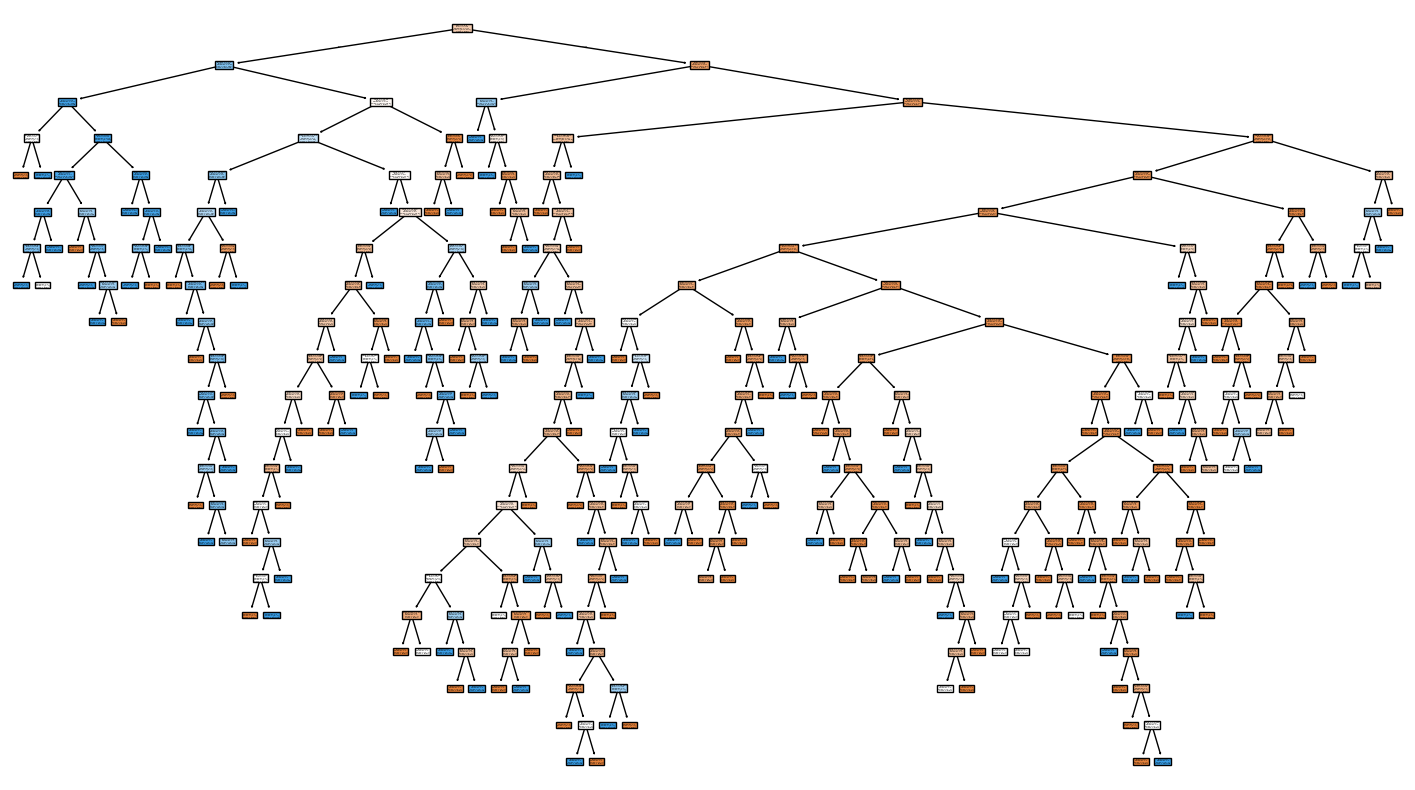

In [23]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survive"],
    filled=True
)

plt.show()

# Decision Tree with Pre-Pruning

In [27]:
max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    print(f"accuracy_score for model with max_depth {depth} :", accuracy_score(y_test,y_pred))

accuracy_score for model with max_depth 2 : 0.7653631284916201
accuracy_score for model with max_depth 3 : 0.7988826815642458
accuracy_score for model with max_depth 4 : 0.7988826815642458
accuracy_score for model with max_depth 5 : 0.7988826815642458
accuracy_score for model with max_depth 6 : 0.8044692737430168
accuracy_score for model with max_depth 7 : 0.7988826815642458
accuracy_score for model with max_depth 8 : 0.7877094972067039
accuracy_score for model with max_depth 9 : 0.7877094972067039
accuracy_score for model with max_depth 10 : 0.7877094972067039


In [31]:
min_samples_split = [5,10,15,20,25,30]

for samples in min_samples_split:
    model = DecisionTreeClassifier(max_depth=4,min_samples_split=samples)
    model.fit(X_train,y_train)

    y_pred = model.predict(X_test)

    print(f"for sample split {samples}, accuracy: ", accuracy_score(y_test,y_pred))

for sample split 5, accuracy:  0.7988826815642458
for sample split 10, accuracy:  0.7988826815642458
for sample split 15, accuracy:  0.7988826815642458
for sample split 20, accuracy:  0.7988826815642458
for sample split 25, accuracy:  0.7932960893854749
for sample split 30, accuracy:  0.7932960893854749


# Decision Tree with post-pruning

In [34]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [40]:
# train our model for all alphas

trees = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train,y_train)

    trees.append((model,alpha))

In [45]:
best_acc = 0
curr_acc = 0

for model,alpha in trees:
     curr_acc = model.score(X_test, y_test)
     if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [46]:
best_acc

0.8379888268156425

In [51]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<Figure size 1800x1000 with 0 Axes>

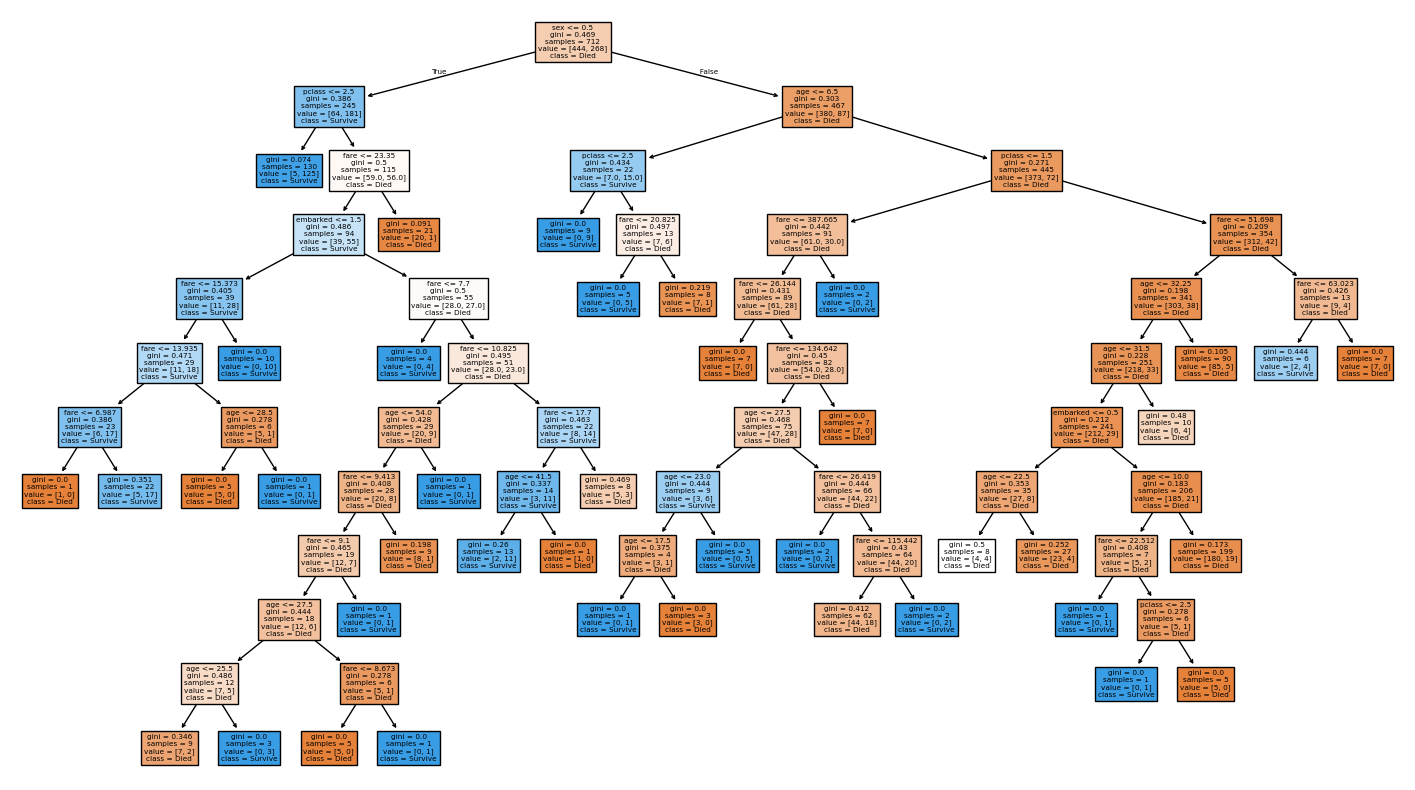

In [52]:
plt.figure(figsize=(18,10))

plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survive"],
    filled=True
)

plt.show()

In [53]:
print(best_model.score(X_test,y_test))

0.8379888268156425
